In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
## performance: per seed performance
## lats_performance: avg over seed performance at the end of training
## last_performance_unnormalized: same as last_performance but without normalization
## max_performance: average over seeds (how?) max performance achieved during training (presumably)

# 1. Normalization

In [4]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(
    lambda g: (g["performance"] - g["_seed_avg"].min()) / (g["_seed_avg"].max() - g["_seed_avg"].min() + 1e-8)
)
data.drop(columns=["_seed_avg"], inplace=True)

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_79477/355322313.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(


In [5]:
y_ = "normed_performance_per_alg_seedavg"

# 2. Metrics

In [6]:
# calc mean and std per config (env_name, algorithm, config_id)
config_stats = data.groupby(["env_name", "algorithm", "config_id"]).agg(
    mean_per_config=(y_, "mean"),
    std_per_config=(y_, "std")
).reset_index()

config_stats.head()

,env_name,algorithm,config_id,mean_per_config,std_per_config
0,atari_battle_zone,dqn,0,0.277003,0.245563
1,atari_battle_zone,dqn,1,0.472877,0.331113
2,atari_battle_zone,dqn,2,0.141822,0.316676
3,atari_battle_zone,dqn,3,0.377482,0.327619
4,atari_battle_zone,dqn,4,0.274940,0.227549


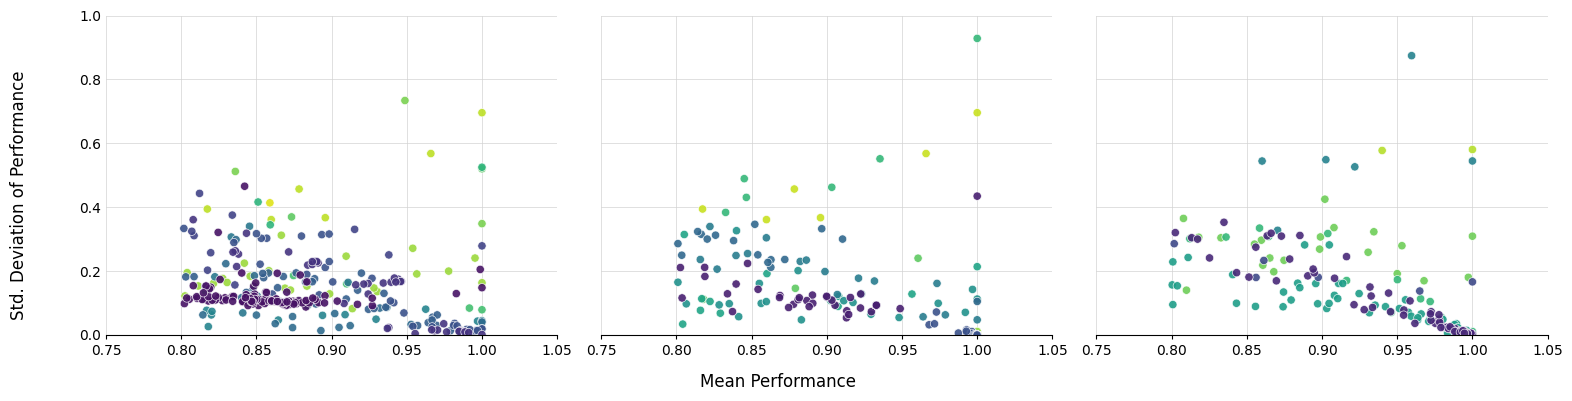

In [7]:
n_cols = 3
algos = data["algorithm"].unique()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True, sharex=True)
axes = axes.flatten()

# Calculate global limits
all_data = config_stats[config_stats["algorithm"].isin(algos)]
x_min, x_max = all_data["mean_per_config"].min(), all_data["mean_per_config"].max()
y_min, y_max = all_data["std_per_config"].min(), all_data["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

for i, alg in enumerate(algos):
    
    sub_data = config_stats[(config_stats["algorithm"] == alg) & (config_stats["mean_per_config"] > 0.8)]

    sns.scatterplot(
        data=sub_data,
        x="mean_per_config",
        y="std_per_config",
        hue="env_name",
        ax=axes[i],
        alpha=0.9,
        palette=sns.color_palette("viridis", n_colors=len(sub_data["env_name"].unique()))[::-1]
    )

    # axes[i].set_title(alg.upper())
    
    # Remove individual axis labels (will use joint labels)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
    # Set same limits
    axes[i].set_xlim(0.75, 1.05)
    # axes[i].set_ylim(y_min - y_margin, y_max + y_margin)
    axes[i].set_ylim(0, 1.0)
    
    # Horizontal and vertical grid lines in light grey
    axes[i].xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].set_axisbelow(True)
    
    # Remove all spines except bottom
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    
    # Remove y ticks but keep labels
    axes[i].tick_params(axis='y', length=0)
    axes[i].tick_params(axis='x', length=3)
    
    # Hide legend
    axes[i].legend().set_visible(False)

# Joint labels
fig.supylabel("Std. Deviation of Performance", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(left=0.08, bottom=0.15)  # Make room for joint labels
# plt.savefig("_figures/mean_std_per_alg.pdf")

## Claim: Std-Dev depends more on env than on algorithm

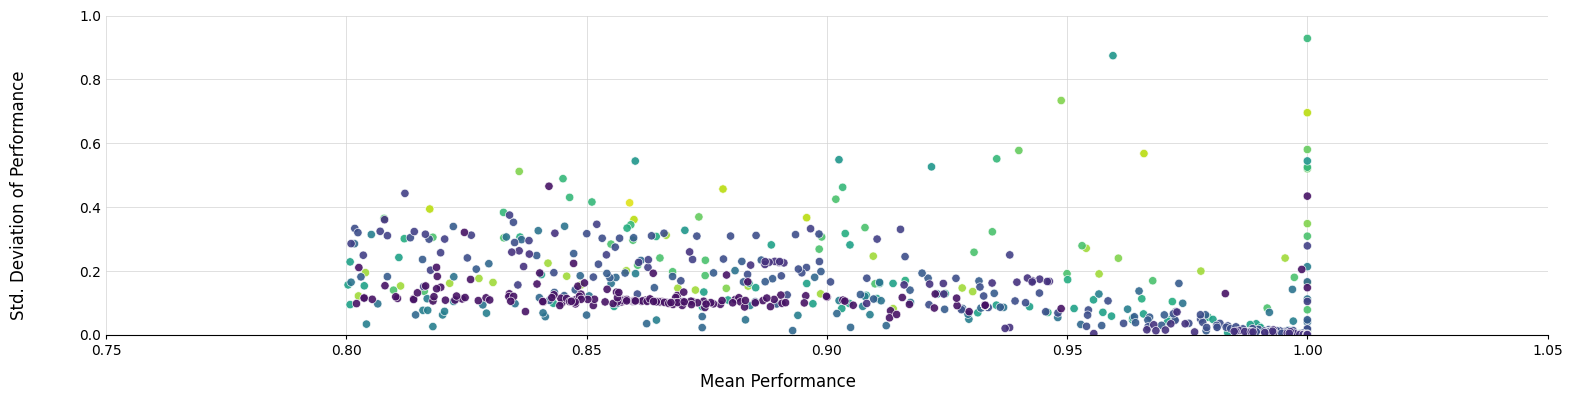

In [8]:
n_cols = 1

fig, axes = plt.subplots(1, 1, figsize=(16, 4), sharey=True, sharex=True)


# Calculate global limits
all_data = config_stats[config_stats["algorithm"].isin(algos)]
x_min, x_max = all_data["mean_per_config"].min(), all_data["mean_per_config"].max()
y_min, y_max = all_data["std_per_config"].min(), all_data["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

    
sub_data = config_stats[(config_stats["mean_per_config"] > 0.8)]

sns.scatterplot(
    data=sub_data,
    x="mean_per_config",
    y="std_per_config",
    hue="env_name",
    ax=axes,
    alpha=0.9,
    palette=sns.color_palette("viridis", n_colors=len(sub_data["env_name"].unique()))[::-1]
)

# axes[i].set_title(alg.upper())

# Remove individual axis labels (will use joint labels)
axes.set_xlabel("")
axes.set_ylabel("")

# Set same limits
axes.set_xlim(0.75, 1.05)
# axes  .set_ylim(y_min - y_margin, y_max + y_margin)
axes.set_ylim(0, 1.0)

# Horizontal and vertical grid lines in light grey
axes.xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
axes.yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
axes.set_axisbelow(True)

# Remove all spines except bottom
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.spines['left'].set_visible(False)

# Remove y ticks but keep labels
axes.tick_params(axis='y', length=0)
axes.tick_params(axis='x', length=3)

# Hide legend
axes.legend().set_visible(False)

# Joint labels
fig.supylabel("Std. Deviation of Performance", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(left=0.08, bottom=0.15)  # Make room for joint labels
# plt.savefig("_figures/mean_std_per_alg.pdf")

In [9]:
# Filter configs where mean_per_config >= 0.8
# Filter configs where mean_per_config >= 0.8
high_perf = config_stats[config_stats["mean_per_config"] >= 0.75]

# Calculate mean of std_per_config for each env-algorithm combination
table = high_perf.groupby(["env_name", "algorithm"])["std_per_config"].mean().unstack()

# replace NaN with "--"
table = table.fillna("--")

# Reset index to make env_name a column, then reorder columns
table = table.reset_index()
table.columns = ["env_name", "dqn", "ppo", "sac"]

table

,env_name,dqn,ppo,sac
0,atari_battle_zone,0.429409,0.421095,--
1,atari_double_dunk,0.518475,0.518475,--
2,atari_phoenix,0.011009,0.178491,--
3,atari_this_game,0.16008,0.531464,--
4,box2d_bipedal_walker,--,0.413269,0.579045
5,box2d_continuous_lunar_lander,--,0.129283,0.277345
6,box2d_lunar_lander,0.522479,0.400571,--
7,brax_ant,--,--,0.19811
8,brax_halfcheetah,--,1.837331,0.100849
9,brax_hopper,--,1.290114,0.565071


In [10]:
cutoff = 0.3 # just arbitrary taken from the table

# select all envs, where all algs are above or all are below that threshold (into separate lists) from the table above
# Only apply replace/astype to the algorithm columns, not env_name
algo_cols = ["dqn", "ppo", "sac"]

table_high = table.copy()
table_high[algo_cols] = table[algo_cols].replace("--", 100.0).infer_objects(copy=False).astype(float)

table_low = table.copy()
table_low[algo_cols] = table[algo_cols].replace("--", 0.0).infer_objects(copy=False).astype(float)

above_cutoff = table_high[(table_high[algo_cols] > cutoff).all(axis=1)]["env_name"].tolist()
below_cutoff = table_low[(table_low[algo_cols] <= cutoff).all(axis=1)]["env_name"].tolist()

# above_cutoff, below_cutoff

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_79477/1476960457.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table_high[algo_cols] = table[algo_cols].replace("--", 100.0).infer_objects(copy=False).astype(float)
/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_79477/1476960457.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table_low[algo_cols] = table[algo_cols].replace("--", 0.0).infer_objects(copy=False).astype(float)


## and now plot the mean-stddev configs seperately

In [11]:
y_ = "normed_performance"

In [12]:
# calc mean and std per config (env_name, algorithm, config_id)
config_stats = data.groupby(["env_name", "algorithm", "config_id"]).agg(
    mean_per_config=(y_, "mean"),
    std_per_config=(y_, "std")
).reset_index()

# config_stats.head()

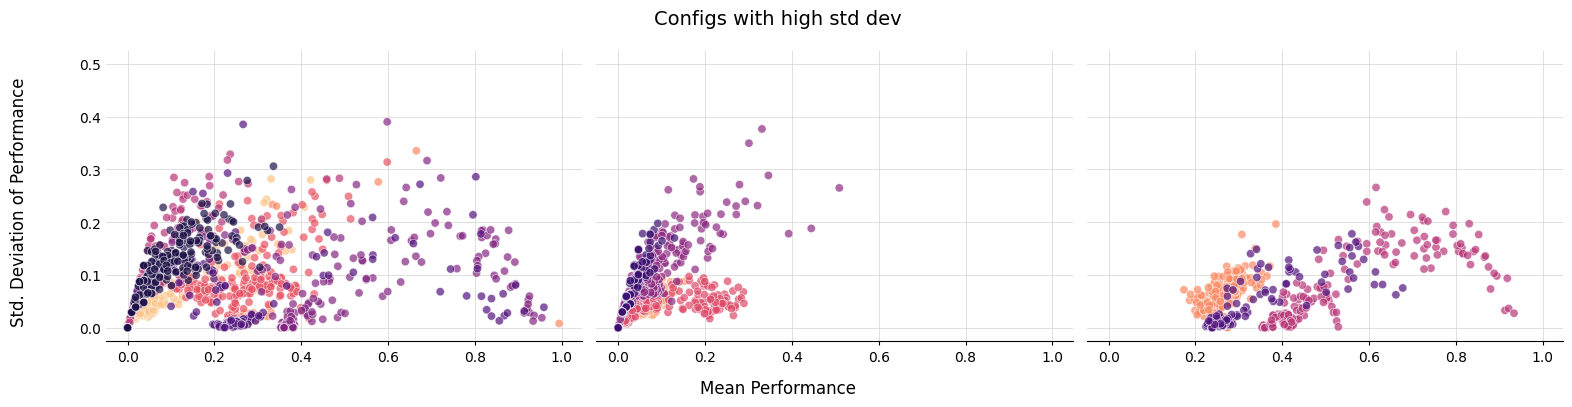

In [13]:
n_cols = 3
algos = data["algorithm"].unique()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True, sharex=True)
axes = axes.flatten()

# Calculate global limits
all_data = config_stats[config_stats["algorithm"].isin(algos)]
x_min, x_max = all_data["mean_per_config"].min(), all_data["mean_per_config"].max()
y_min, y_max = all_data["std_per_config"].min(), all_data["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

for i, alg in enumerate(algos):
    
    sub_data = config_stats[(config_stats["algorithm"] == alg) & (config_stats["env_name"].isin(above_cutoff))]

    sns.scatterplot(
        data=sub_data,
        x="mean_per_config",
        y="std_per_config",
        hue="env_name",
        ax=axes[i],
        alpha=0.7,
        palette=sns.color_palette("magma", n_colors=len(sub_data["env_name"].unique()))[::-1]
    )

    # axes[i].set_title(alg.upper())
    
    # Remove individual axis labels (will use joint labels)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
    # Set same limits
    axes[i].set_xlim(x_min - x_margin, x_max + x_margin)
    axes[i].set_ylim(y_min - y_margin, y_max + y_margin)
    
    # Horizontal and vertical grid lines in light grey
    axes[i].xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].set_axisbelow(True)
    
    # Remove all spines except bottom
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    
    # Remove y ticks but keep labels
    axes[i].tick_params(axis='y', length=0)
    axes[i].tick_params(axis='x', length=3)
    
    # Hide legend
    axes[i].legend().set_visible(False)

# Joint labels
fig.supylabel("Std. Deviation of Performance", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)
fig.suptitle("Configs with high std dev", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(left=0.08, bottom=0.15)  # Make room for joint labels
# plt.savefig("_figures/mean_std_per_alg_u.pdf")

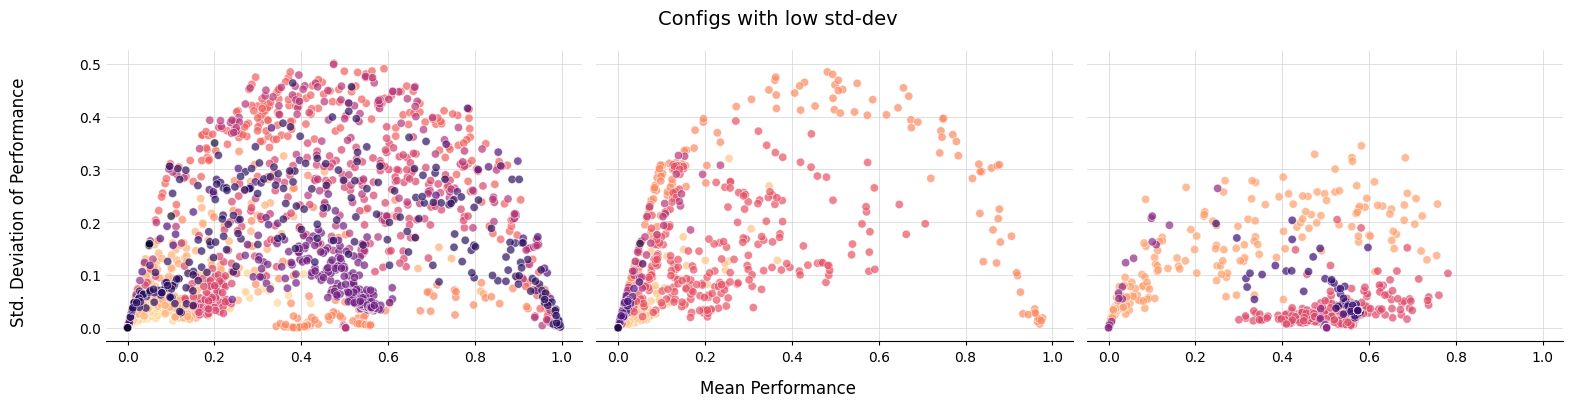

In [ ]:
n_cols = 3
algos = data["algorithm"].unique()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True, sharex=True)
axes = axes.flatten()

# Calculate global limits
all_data = config_stats[config_stats["algorithm"].isin(algos)]
x_min, x_max = all_data["mean_per_config"].min(), all_data["mean_per_config"].max()
y_min, y_max = all_data["std_per_config"].min(), all_data["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

for i, alg in enumerate(algos):
    
    sub_data = config_stats[(config_stats["algorithm"] == alg) & (config_stats["env_name"].isin(below_cutoff))]

    sns.scatterplot(
        data=sub_data,
        x="mean_per_config",
        y="std_per_config",
        hue="env_name",
        ax=axes[i],
        alpha=0.7,
        palette=sns.color_palette("magma", n_colors=len(sub_data["env_name"].unique()))[::-1]
    )

    # axes[i].set_title(alg.upper())
    
    # Remove individual axis labels (will use joint labels)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
    # Set same limits
    axes[i].set_xlim(x_min - x_margin, x_max + x_margin)
    axes[i].set_ylim(y_min - y_margin, y_max + y_margin)
    
    # Horizontal and vertical grid lines in light grey
    axes[i].xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].set_axisbelow(True)
    
    # Remove all spines except bottom
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    
    # Remove y ticks but keep labels
    axes[i].tick_params(axis='y', length=0)
    axes[i].tick_params(axis='x', length=3)
    
    # Hide legend
    axes[i].legend().set_visible(False)

# Joint labels
fig.supylabel("Std. Deviation of Performance", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)
fig.suptitle("Configs with low std-dev", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(left=0.08, bottom=0.15)  # Make room for joint labels
# plt.savefig("_figures/mean_std_per_alg_u.pdf")

In [15]:
config_stats.head()

,env_name,algorithm,config_id,mean_per_config,std_per_config
0,atari_battle_zone,dqn,0,0.038784,0.030913
1,atari_battle_zone,dqn,1,0.080277,0.063958
2,atari_battle_zone,dqn,2,0.040349,0.055413
3,atari_battle_zone,dqn,3,0.089045,0.046115
4,atari_battle_zone,dqn,4,0.059189,0.038576


In [16]:
def LCB(mean, std):
    return mean - std

def Sharpe(mean, std):
    return mean / (std + 1e-8)

def mean_(mean, std):
    return mean

def get_nested_data(config_stats, value_func):
    algorithms = config_stats["algorithm"].unique().tolist()
    env_names = config_stats["env_name"].unique().tolist()

    nested_data = []
    for algo in algorithms:
        algo_list = []
        for env in env_names:
            # Filter for this algo-env combination
            subset = config_stats[
                (config_stats["algorithm"] == algo) & 
                (config_stats["env_name"] == env)
            ]
            # Apply function to each config_id's mean and std
            config_values = [
                value_func(row["mean_per_config"], row["std_per_config"])
                for _, row in subset.iterrows()
            ]
            algo_list.append(config_values)
        nested_data.append(algo_list)
    
    return nested_data

In [17]:
def anova_decomposition_irregular(nested_data_algo):
    """
    Perform two-way ANOVA decomposition for one algorithm's data with irregular shapes.
    
    Args:
        nested_data_algo: List of lists, where nested_data_algo[a] contains
                         values for environment a (can have different lengths)
    
    Returns:
        dict with SS_T, SS_env (env), SS_H (residual/within), and eta-squared values
    """
    A = len(nested_data_algo)
    
    # Flatten all values and compute grand mean
    all_values = [v for env_list in nested_data_algo for v in env_list]
    N = len(all_values)
    grand_mean = np.mean(all_values)
    
    # Row means (per environment)
    row_means = [np.mean(env_list) if len(env_list) > 0 else 0 for env_list in nested_data_algo]
    row_counts = [len(env_list) for env_list in nested_data_algo]
    
    # Total sum of squares
    SS_T = sum((v - grand_mean) ** 2 for v in all_values)
    
    # Between-group (environment effect): n_a * (x_bar_a - x_bar)^2
    SS_env = sum(
        n_a * (x_bar_a - grand_mean) ** 2 
        for n_a, x_bar_a in zip(row_counts, row_means)
    )
    
    # Within-group (residual/config effect within each env)
    SS_config = sum(
        (v - row_means[a]) ** 2
        for a, env_list in enumerate(nested_data_algo)
        for v in env_list
    )
    
    # SS_T = SS_env + SS_config (one-way decomposition for irregular data)
    
    # Eta-squared
    eta_env = SS_env / SS_T if SS_T > 0 else 0
    eta_config = SS_config / SS_T if SS_T > 0 else 0
    
    return {
        "SS_T": SS_T,
        "SS_env": SS_env,      # between environments
        "SS_config": SS_config,      # within environments (configs)
        "eta_env": eta_env,    # proportion due to environment
        "eta_config": eta_config,    # proportion due to config (within-env)
        "A": A,
        "N": N
    }


def run_anova_per_algorithm(nested_data, algorithms):
    """
    Run ANOVA decomposition for each algorithm.
    """
    results = []
    for algo_idx, algo in enumerate(algorithms):
        result = anova_decomposition_irregular(nested_data[algo_idx])
        result["algorithm"] = algo
        results.append(result)
    
    df = pd.DataFrame(results)
    df = df[["algorithm", "eta_env", "eta_config", "SS_env", "SS_config", "SS_T", "A", "N"]]
    return df


## Std for high performing configs

In [18]:
high_perf_data = config_stats[config_stats["mean_per_config"] >= 0.85]

nested_data = get_nested_data(high_perf_data, mean_)

anova_results = run_anova_per_algorithm(nested_data, algos)

anova_results

,algorithm,eta_env,eta_config,SS_env,SS_config,SS_T,A,N
0,ppo,0.160616,0.839384,0.054238,0.283447,0.337684,9,188
1,dqn,0.000000,1.000000,0.000000,0.007051,0.007051,9,11
2,sac,0.000000,1.000000,0.000000,0.042032,0.042032,9,24


# Doesn't really work; back to square one, just look at cumulative data for all algorithms on all of the data

In [23]:
y_ = "normed_performance_per_alg_seedavg"

In [24]:
# calc mean and std per config (env_name, algorithm, config_id)
config_stats = data.groupby(["env_name", "algorithm", "config_id"]).agg(
    mean_per_config=(y_, "mean"),
    std_per_config=(y_, "std")
).reset_index()


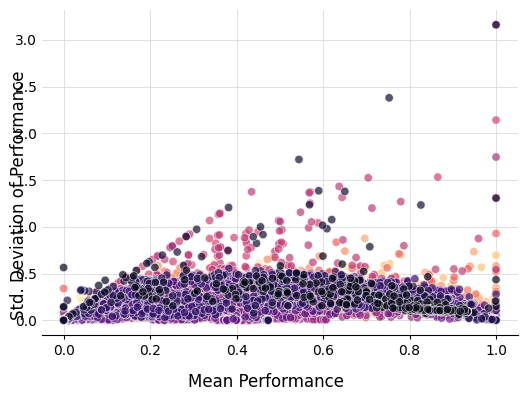

In [25]:
n_cols = 1
algos = data["algorithm"].unique()

fig, ax = plt.subplots(1, 1, figsize=(16/3, 4), sharey=True, sharex=True)

# Calculate global limits
all_data = config_stats[config_stats["algorithm"].isin(algos)]
x_min, x_max = all_data["mean_per_config"].min(), all_data["mean_per_config"].max()
y_min, y_max = all_data["std_per_config"].min(), all_data["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

sns.scatterplot(
    data=config_stats,
    x="mean_per_config",
    y="std_per_config",
    hue="env_name",
    ax=ax,
    alpha=0.7,
    palette=sns.color_palette("magma", n_colors=len(config_stats["env_name"].unique()))[::-1]
)

# Remove individual axis labels (will use joint labels)
ax.set_xlabel("")
ax.set_ylabel("")

# Set same limits
ax.set_xlim(x_min - x_margin, x_max + x_margin)
ax.set_ylim(y_min - y_margin, y_max + y_margin)

# Horizontal and vertical grid lines in light grey
ax.xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
ax.yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Remove all spines except bottom
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove y ticks but keep labels
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=3)

# Hide legend
ax.legend().set_visible(False)

# Joint labels
fig.supylabel("Std. Deviation of Performance", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)
# fig.suptitle("Configs with low std-dev", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(left=0.08, bottom=0.15)

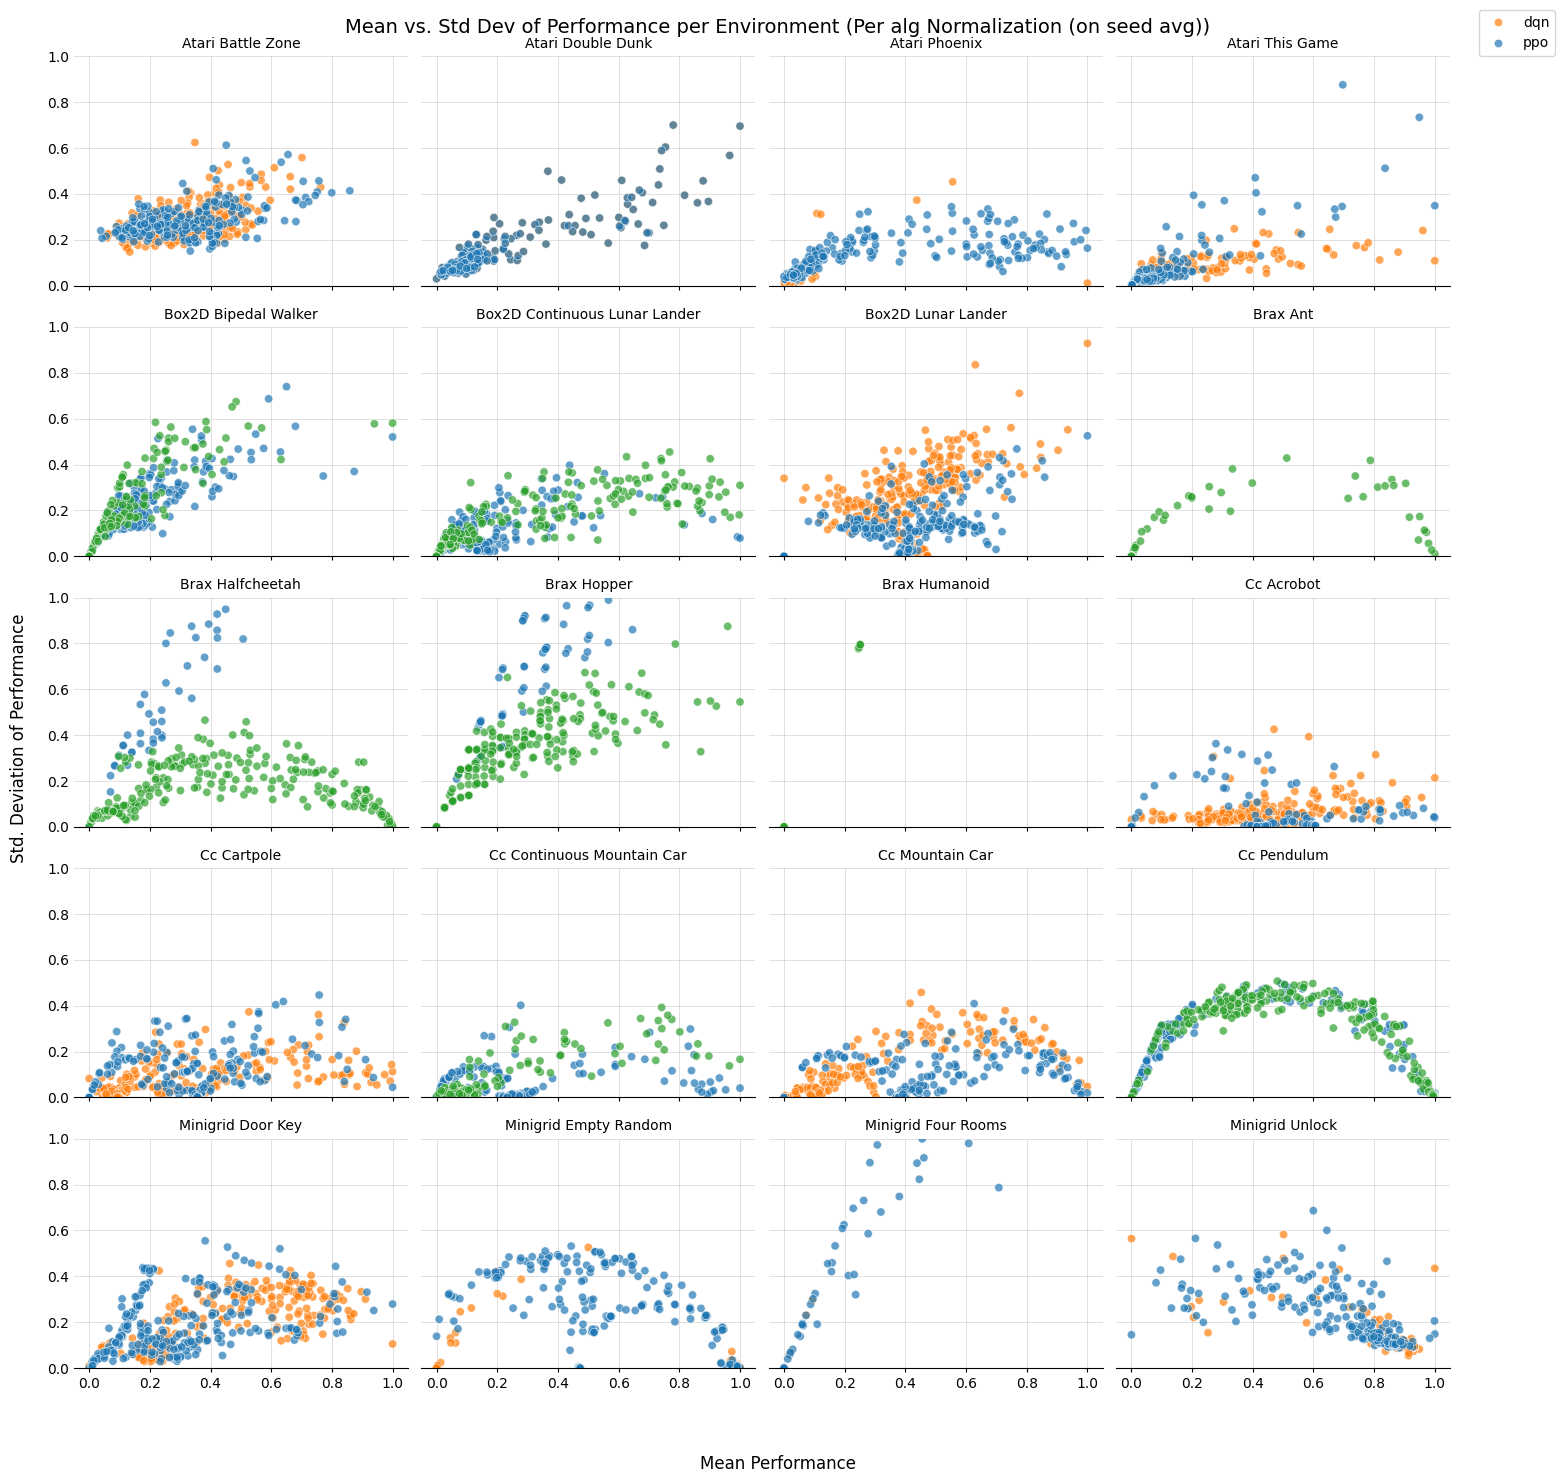

In [ ]:
env_names = config_stats["env_name"].unique()
n_envs = len(env_names)
n_cols = 4
n_rows = int(np.ceil(n_envs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows), sharey=True, sharex=True)
axes = axes.flatten()

# Calculate global limits
x_min, x_max = config_stats["mean_per_config"].min(), config_stats["mean_per_config"].max()
y_min, y_max = config_stats["std_per_config"].min(), config_stats["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

# Color palette for algorithms
algo_palette = {"ppo": "#1f77b4", "dqn": "#ff7f0e", "sac": "#2ca02c"}

for i, env in enumerate(env_names):
    ax = axes[i]
    
    sub_data = config_stats[config_stats["env_name"] == env]
    
    sns.scatterplot(
        data=sub_data,
        x="mean_per_config",
        y="std_per_config",
        hue="algorithm",
        ax=ax,
        alpha=0.7,
        palette=algo_palette
    )
    
    ax.set_title(env.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Set same limits
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    # ax.set_ylim(y_min - y_margin, y_max + y_margin)
    ax.set_ylim(0, 1.0)
    
    # Grid
    ax.xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', length=3)
    
    # Hide individual legends
    ax.legend().set_visible(False)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Joint labels
fig.supylabel("Std. Deviation of Performance", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)

# Add shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.99))

# full title for the whole plot
fig.suptitle(f"Mean vs. Std Dev of y={y_}", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(left=0.06, bottom=0.08, right=0.92)

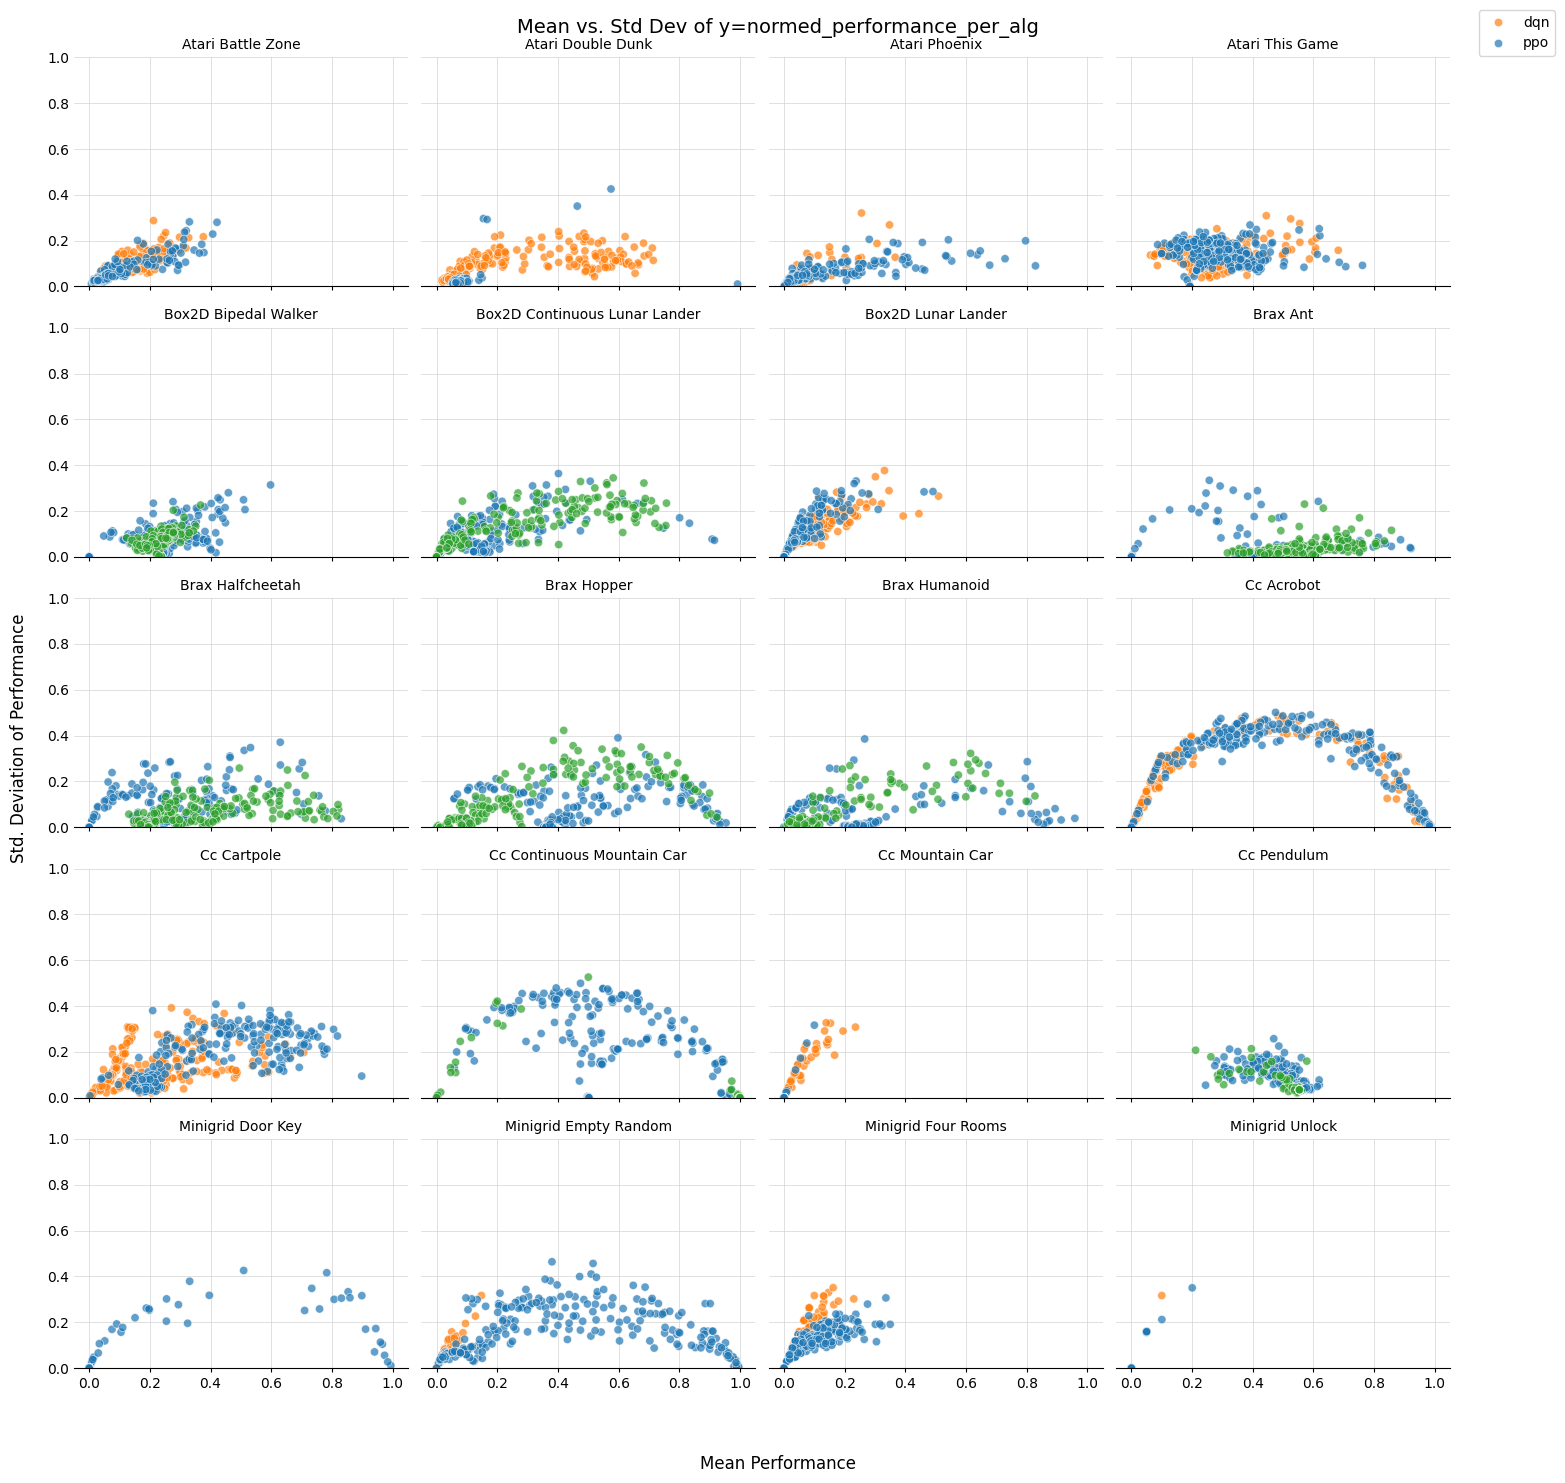

In [29]:
y_ = "normed_performance_per_alg"

# calc mean and std per config (env_name, algorithm, config_id)
config_stats = data.groupby(["env_name", "algorithm", "config_id"]).agg(
    mean_per_config=(y_, "mean"),
    std_per_config=(y_, "std")
).reset_index()

env_names = config_stats["env_name"].unique()
n_envs = len(env_names)
n_cols = 4
n_rows = int(np.ceil(n_envs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows), sharey=True, sharex=True)
axes = axes.flatten()

# Calculate global limits
x_min, x_max = config_stats["mean_per_config"].min(), config_stats["mean_per_config"].max()
y_min, y_max = config_stats["std_per_config"].min(), config_stats["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

# Color palette for algorithms
algo_palette = {"ppo": "#1f77b4", "dqn": "#ff7f0e", "sac": "#2ca02c"}

for i, env in enumerate(env_names):
    ax = axes[i]
    
    sub_data = config_stats[config_stats["env_name"] == env]
    
    sns.scatterplot(
        data=sub_data,
        x="mean_per_config",
        y="std_per_config",
        hue="algorithm",
        ax=ax,
        alpha=0.7,
        palette=algo_palette
    )
    
    ax.set_title(env.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Set same limits
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    # ax.set_ylim(y_min - y_margin, y_max + y_margin)
    ax.set_ylim(0, 1.0)
    
    # Grid
    ax.xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', length=3)
    
    # Hide individual legends
    ax.legend().set_visible(False)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Joint labels
fig.supylabel("Std. Deviation of Performance", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)

# Add shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.99))

# full title for the whole plot
fig.suptitle(f"Mean vs. Std Dev of y={y_}", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(left=0.06, bottom=0.08, right=0.92)

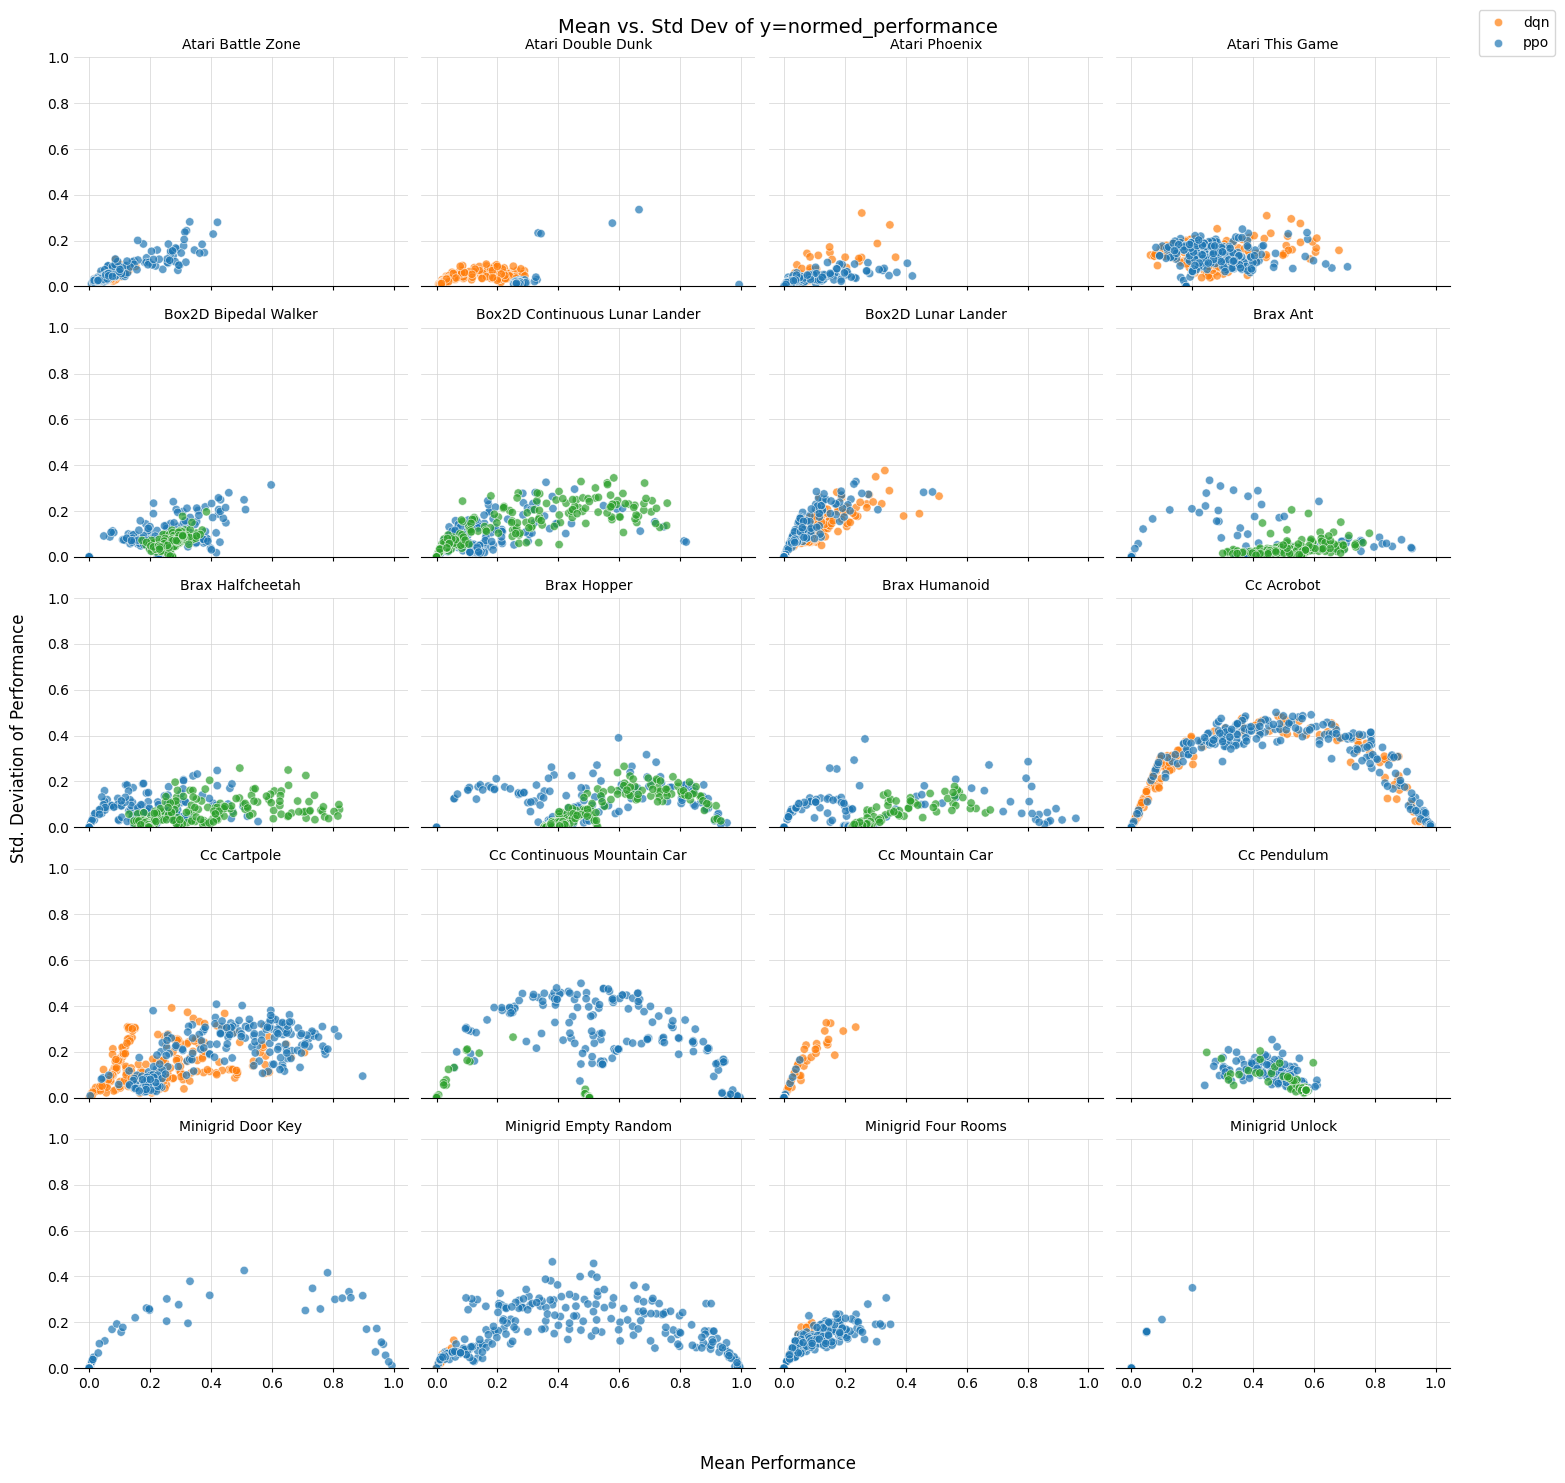

In [30]:
y_ = "normed_performance"

# calc mean and std per config (env_name, algorithm, config_id)
config_stats = data.groupby(["env_name", "algorithm", "config_id"]).agg(
    mean_per_config=(y_, "mean"),
    std_per_config=(y_, "std")
).reset_index()

env_names = config_stats["env_name"].unique()
n_envs = len(env_names)
n_cols = 4
n_rows = int(np.ceil(n_envs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows), sharey=True, sharex=True)
axes = axes.flatten()

# Calculate global limits
x_min, x_max = config_stats["mean_per_config"].min(), config_stats["mean_per_config"].max()
y_min, y_max = config_stats["std_per_config"].min(), config_stats["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

# Color palette for algorithms
algo_palette = {"ppo": "#1f77b4", "dqn": "#ff7f0e", "sac": "#2ca02c"}

for i, env in enumerate(env_names):
    ax = axes[i]
    
    sub_data = config_stats[config_stats["env_name"] == env]
    
    sns.scatterplot(
        data=sub_data,
        x="mean_per_config",
        y="std_per_config",
        hue="algorithm",
        ax=ax,
        alpha=0.7,
        palette=algo_palette
    )
    
    ax.set_title(env.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Set same limits
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    # ax.set_ylim(y_min - y_margin, y_max + y_margin)
    ax.set_ylim(0, 1.0)
    
    # Grid
    ax.xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', length=3)
    
    # Hide individual legends
    ax.legend().set_visible(False)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Joint labels
fig.supylabel("Std. Deviation of Performance", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)

# Add shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.99))

# full title for the whole plot
fig.suptitle(f"Mean vs. Std Dev of y={y_}", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(left=0.06, bottom=0.08, right=0.92)